In [1]:
from inference import EvaluateModelOnnx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
def plot_all_metrics_single_figure(df):
    metrics = ["Precision", "Recall", "F1"]
    frequencies = ["LowerLow","Low","Medium","High","Random"]
    attacks = ["DoS","Fuzz","Replay"]

    colors = {"DoS":"tab:red","Fuzz":"tab:blue","Replay":"tab:green"}

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(8, 8),
        sharex=True
    )

    x = np.arange(len(frequencies))
    width = 0.22

    for ax, metric in zip(axes, metrics):
        for i, attack in enumerate(attacks):
            subset = (
                df[(df["Metric"] == metric) & (df["Attack"] == attack)]
                .set_index("Frequency")
                .loc[frequencies]
            )

            y = subset["Value"].values
            yerr = [
                y - subset["CI_L"].values,
                subset["CI_H"].values - y
            ]

            ax.errorbar(
                x + (i - 1) * width,
                y,
                yerr=yerr,
                fmt='o',
                capsize=7,
                color=colors[attack],
                markersize=5,
                label=attack if metric == "Precision" else None
            )

        ax.set_ylabel(metric, fontsize=12, fontweight="bold")
        ax.set_ylim(0.82, 1.01)
        ax.grid(True, linestyle="--", alpha=0.75)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(frequencies, fontsize=11, fontweight="bold")
    axes[-1].set_xlabel("Attack Frequency", fontsize=13, fontweight="bold")

    legend = axes[0].legend(
        title="Attack Type",
        fontsize=10,
        frameon=True,
        loc="upper right",
        prop={"weight": "bold"}   # legend labels
    )

    legend.get_title().set_fontweight("bold")
    legend.get_title().set_fontsize(10)

    plt.tight_layout()
    # plt.savefig("ids_all_metrics_ci.pdf", bbox_inches="tight")
    plt.savefig("ids_all_metrics_ci.png", dpi=1000, bbox_inches="tight")
    plt.show()

## Tran on Kia

## Test on Tesla DoS

In [3]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainKiaOnnx"
TIME_GAP = 83.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.78it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:03<00:00, 13.04it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.8986  (95% CI: 0.8759, 0.9176)
Precision: 0.8626  (95% CI: 0.8235, 0.8942)
Recall   : 0.9075  (95% CI: 0.8724, 0.9337)
F1-score : 0.8845  (95% CI: 0.8579, 0.9076)


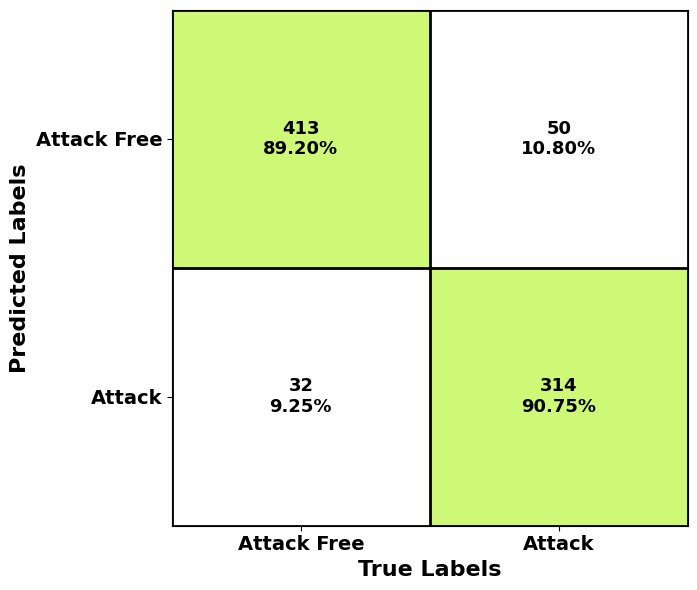

In [4]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)



--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:06<00:00,  3.22s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.23it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9135, 0.9507)


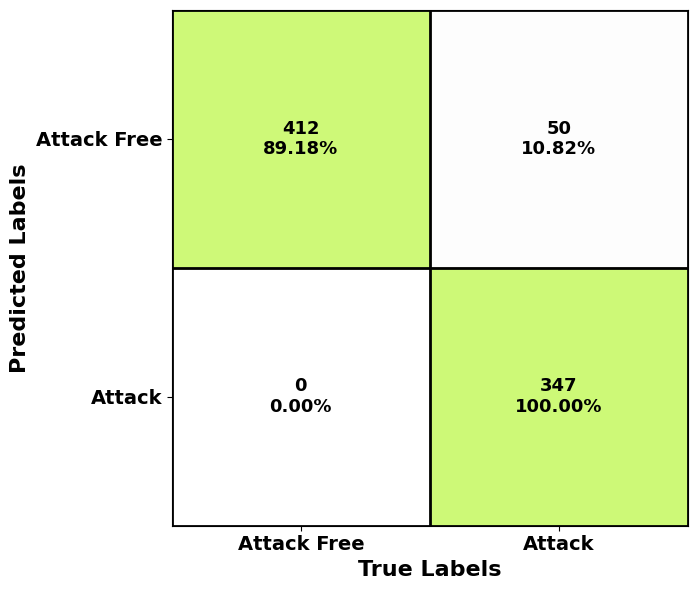

In [5]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)



--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:03<00:00,  1.74s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


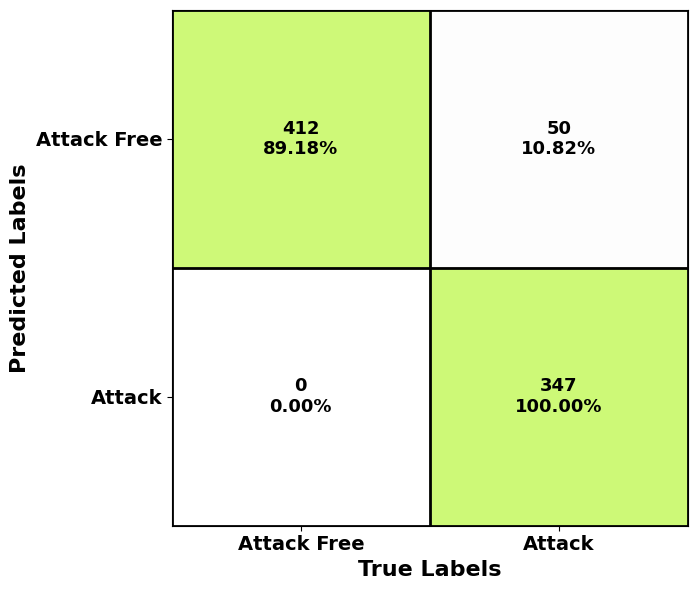

In [6]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)



--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:08<00:00,  4.42s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9135, 0.9507)


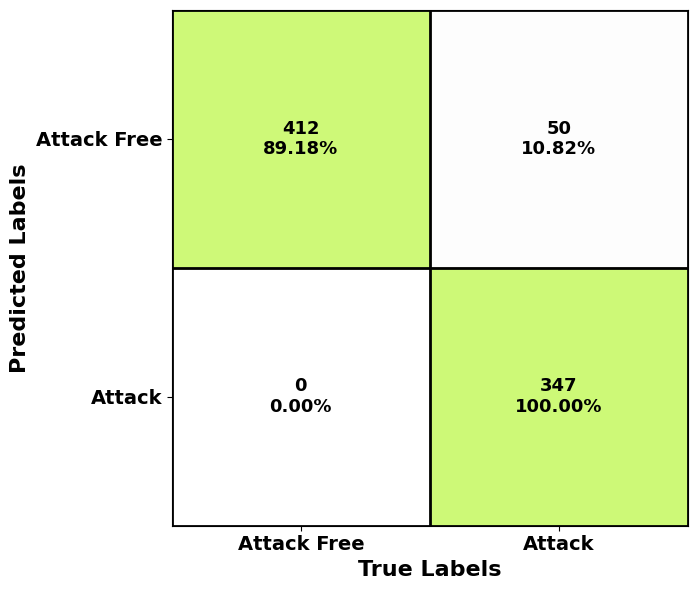

In [7]:
DATA_DIR = "Split_data/Test/Tesla/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)



--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.39s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.21it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9135, 0.9507)


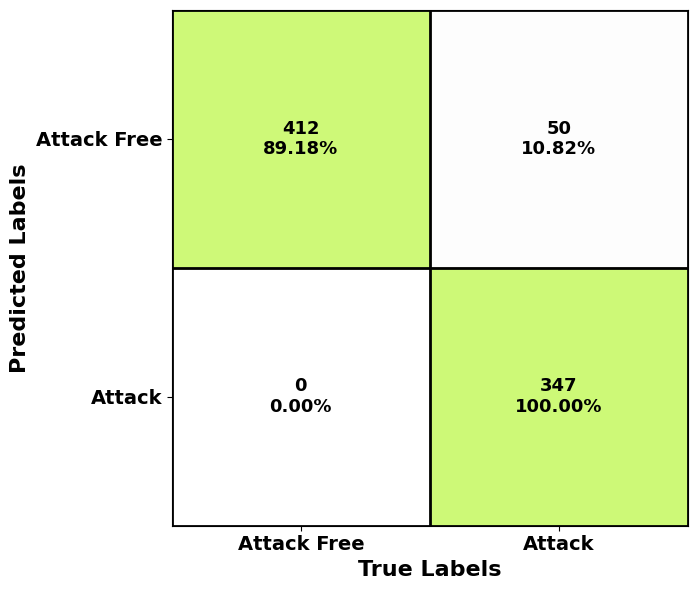

In [8]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


## Test on Tesla Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:05<00:00,  2.82s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.24it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9308  (95% CI: 0.9112, 0.9463)
Precision: 0.8718  (95% CI: 0.8350, 0.9014)
Recall   : 0.9827  (95% CI: 0.9627, 0.9920)
F1-score : 0.9239  (95% CI: 0.9038, 0.9427)


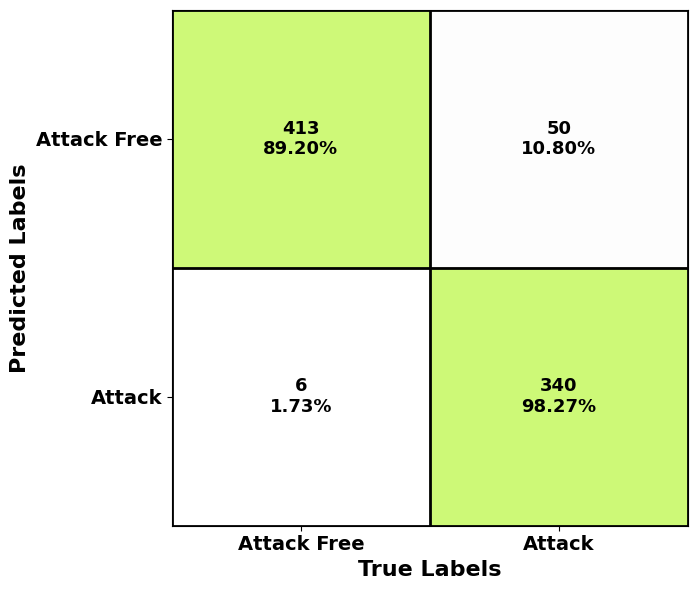

In [9]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.27s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.24it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9370  (95% CI: 0.9181, 0.9517)
Precision: 0.8737  (95% CI: 0.8374, 0.9029)
Recall   : 0.9971  (95% CI: 0.9839, 0.9995)
F1-score : 0.9314  (95% CI: 0.9125, 0.9493)


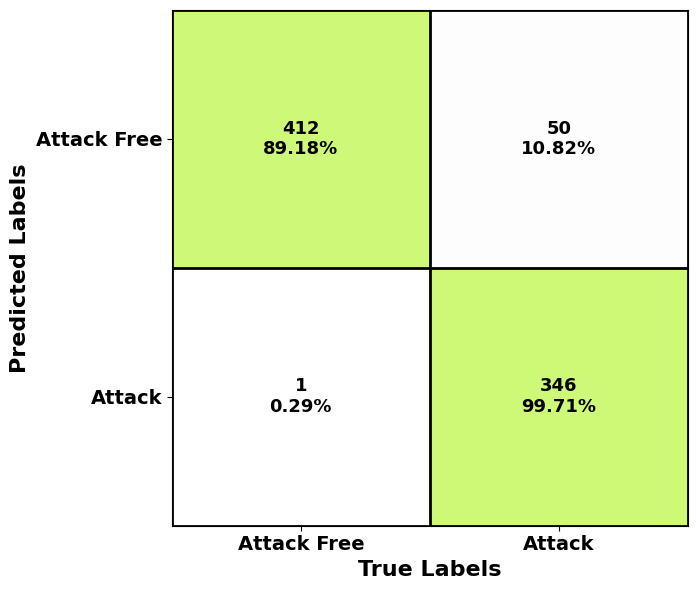

In [10]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:03<00:00,  1.86s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.21it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


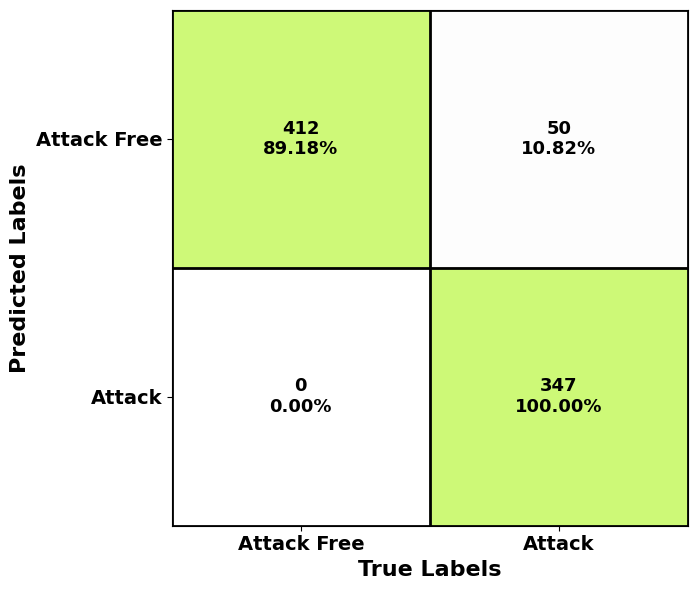

In [11]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:05<00:00,  2.66s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


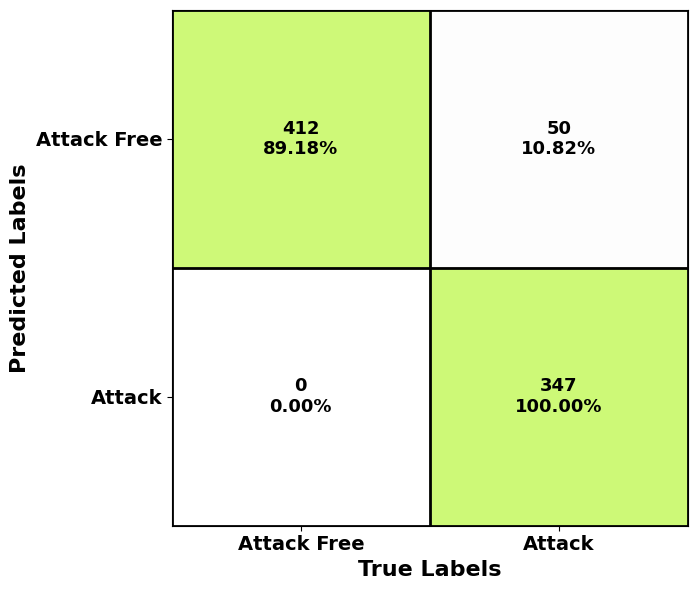

In [12]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:07<00:00,  3.57s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.21it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


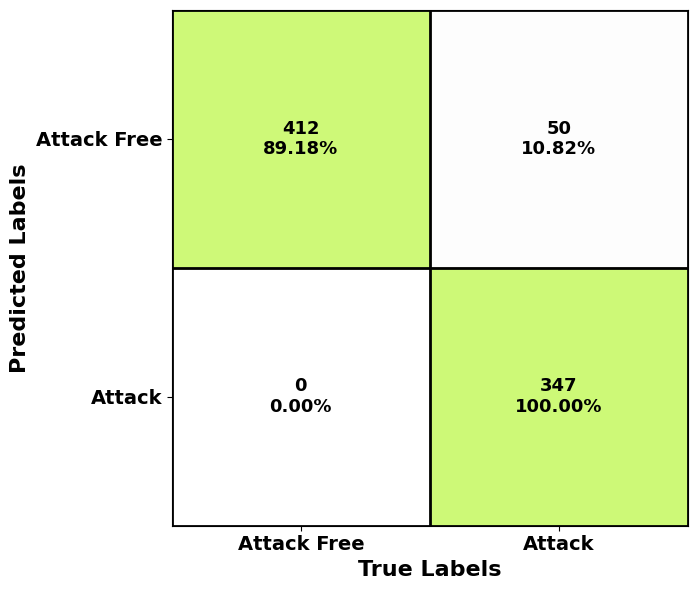

In [13]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Test on Tesla Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:06<00:00,  3.38s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.24it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8737  (95% CI: 0.8374, 0.9029)
Recall   : 1.0000  (95% CI: 0.9890, 1.0000)
F1-score : 0.9326  (95% CI: 0.9139, 0.9503)


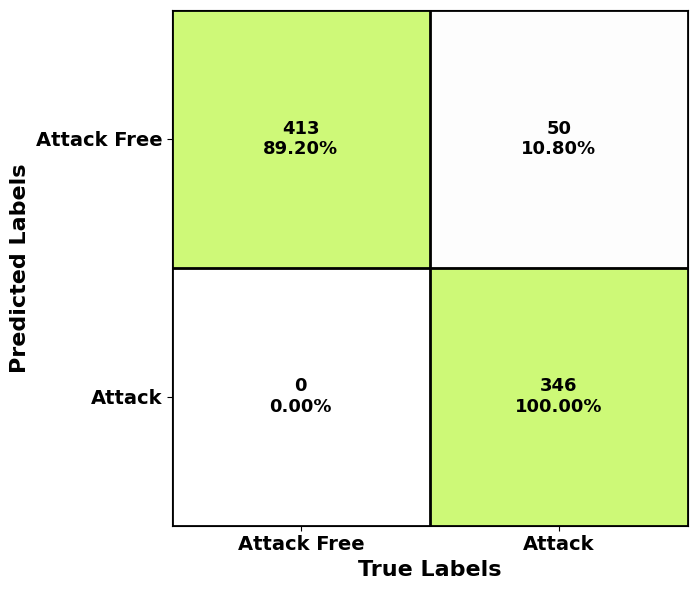

In [14]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.25s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.19it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


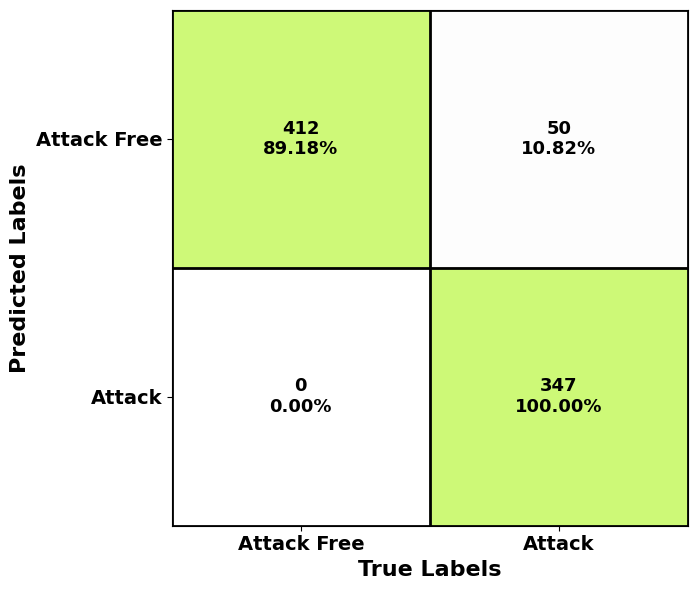

In [15]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.19s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.19it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


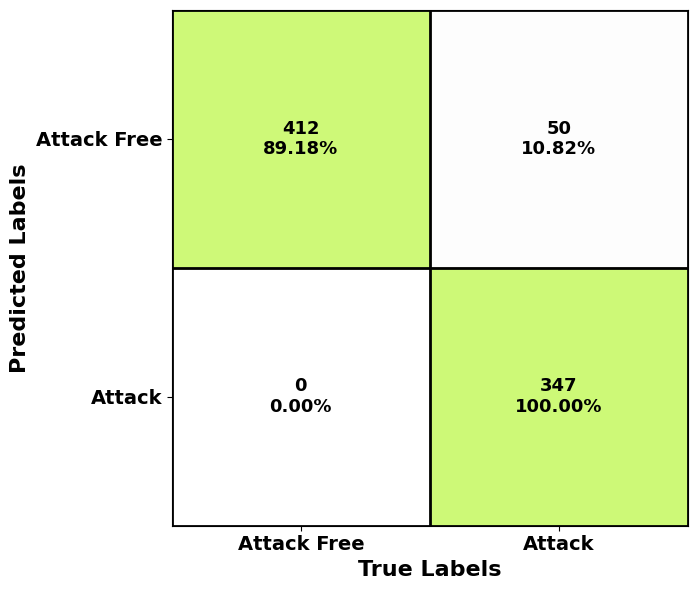

In [16]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.38s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.18it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


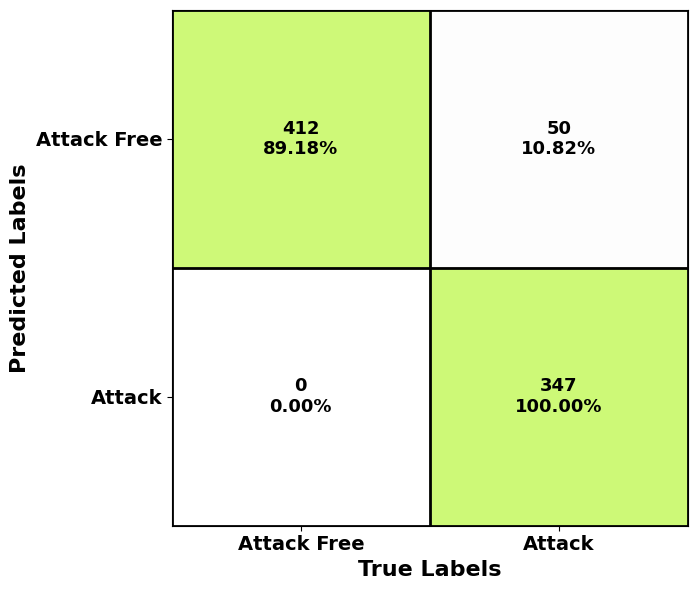

In [17]:
DATA_DIR = "Split_data/Test/Tesla/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:05<00:00,  2.68s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


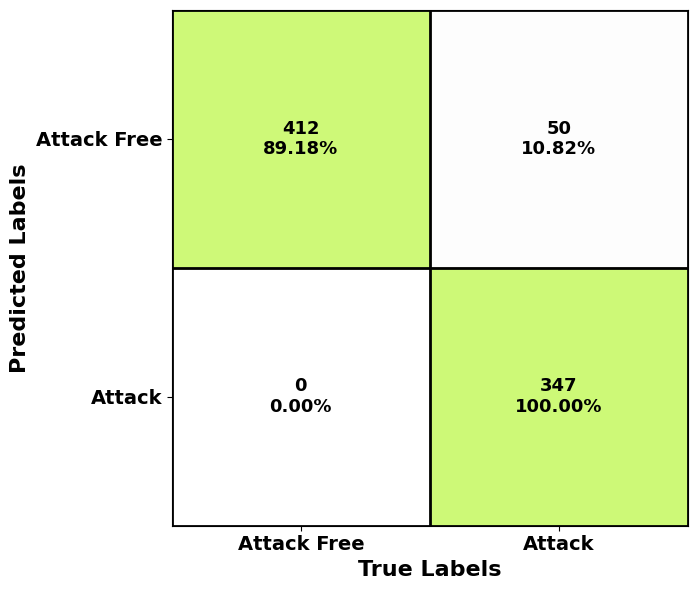

In [18]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

In [ ]:
df = pd.DataFrame([
    # Attack, Frequency, Metric, Value, CI_low, CI_high

    # ---- DoS ----
    ("DoS","LowerLow","Precision",0.8626,0.8235,0.8942),
    ("DoS","LowerLow","Recall",0.9075,0.8724,0.9337),
    ("DoS","LowerLow","F1",0.8845,0.8579,0.9076),

    ("DoS","Low","Precision",0.8741,0.8378,0.9031),
    ("DoS","Low","Recall",1.0000,0.9891,1.0000),
    ("DoS","Low","F1",0.9328,0.9135,0.9507),

    ("DoS","Medium","Precision",0.8741,0.8378,0.9031),
    ("DoS","Medium","Recall",1.0000,0.9891,1.0000),
    ("DoS","Medium","F1",0.9328,0.9143,0.9505),

    ("DoS","High","Precision",0.8741,0.8378,0.9031),
    ("DoS","High","Recall",1.0000,0.9891,1.0000),
    ("DoS","High","F1",0.9328,0.9135,0.9507),

    ("DoS","Random","Precision",0.8741,0.8378,0.9031),
    ("DoS","Random","Recall",1.0000,0.9891,1.0000),
    ("DoS","Random","F1",0.9328,0.9135,0.9507),

    # ---- Fuzz ----
    ("Fuzz","LowerLow","Precision",0.8718,0.8350,0.9014),
    ("Fuzz","LowerLow","Recall",0.9827,0.9627,0.9920),
    ("Fuzz","LowerLow","F1",0.9239,0.9038,0.9427),

    ("Fuzz","Low","Precision",0.8737,0.8374,0.9029),
    ("Fuzz","Low","Recall",0.9971,0.9839,0.9995),
    ("Fuzz","Low","F1",0.9314,0.9125,0.9493),

    ("Fuzz","Medium","Precision",0.8741,0.8378,0.9031),
    ("Fuzz","Medium","Recall",1.0000,0.9891,1.0000),
    ("Fuzz","Medium","F1",0.9328,0.9143,0.9505),

    ("Fuzz","High","Precision",0.8741,0.8378,0.9031),
    ("Fuzz","High","Recall",1.0000,0.9891,1.0000),
    ("Fuzz","High","F1",0.9328,0.9143,0.9505),

    ("Fuzz","Random","Precision",0.8741,0.8378,0.9031),
    ("Fuzz","Random","Recall",1.0000,0.9891,1.0000),
    ("Fuzz","Random","F1",0.9328,0.9143,0.9505),

    # ---- Replay ----
    ("Replay","LowerLow","Precision",0.8737,0.8374,0.9029),
    ("Replay","LowerLow","Recall",1.0000,0.9890,1.0000),
    ("Replay","LowerLow","F1",0.9326,0.9139,0.9503),

    ("Replay","Low","Precision",0.8741,0.8378,0.9031),
    ("Replay","Low","Recall",1.0000,0.9891,1.0000),
    ("Replay","Low","F1",0.9328,0.9143,0.9505),

    ("Replay","Medium","Precision",0.8741,0.8378,0.9031),
    ("Replay","Medium","Recall",1.0000,0.9891,1.0000),
    ("Replay","Medium","F1",0.9328,0.9143,0.9505),

    ("Replay","High","Precision",0.8741,0.8378,0.9031),
    ("Replay","High","Recall",1.0000,0.9891,1.0000),
    ("Replay","High","F1",0.9328,0.9143,0.9505),

    ("Replay","Random","Precision",0.8741,0.8378,0.9031),
    ("Replay","Random","Recall",1.0000,0.9891,1.0000),
    ("Replay","Random","F1",0.9328,0.9143,0.9505),
], columns=["Attack","Frequency","Metric","Value","CI_L","CI_H"])

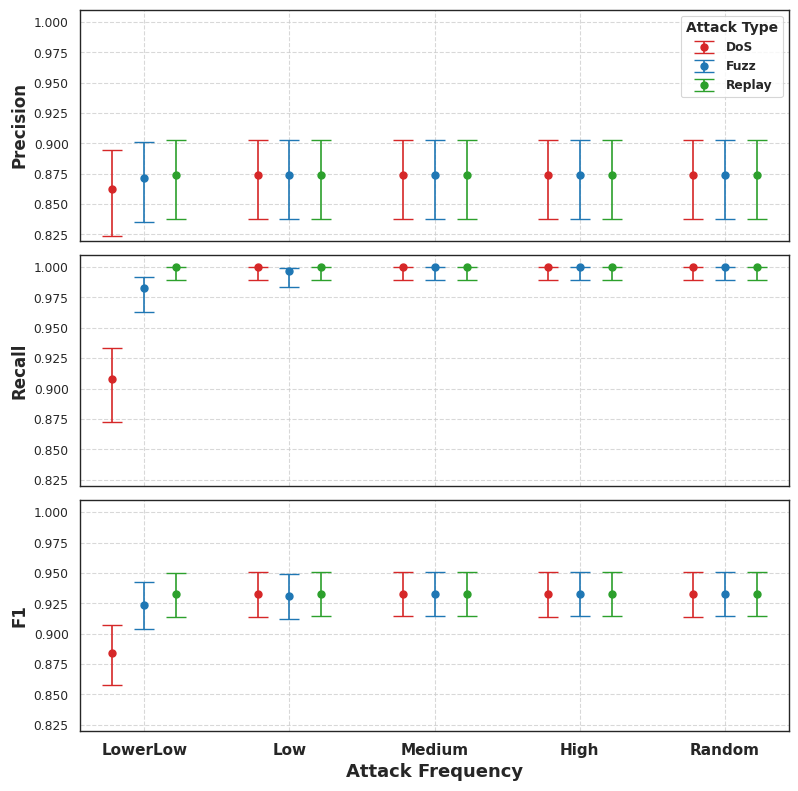

In [64]:
plot_all_metrics_single_figure(df)

## Test on Tesla Gennesis

In [9]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainKiaOnnx"
TIME_GAP = 105.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.63it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.10it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9458  (95% CI: 0.9278, 0.9595)
Precision: 0.9685  (95% CI: 0.9429, 0.9828)
Recall   : 0.9029  (95% CI: 0.8668, 0.9301)
F1-score : 0.9346  (95% CI: 0.9144, 0.9527)


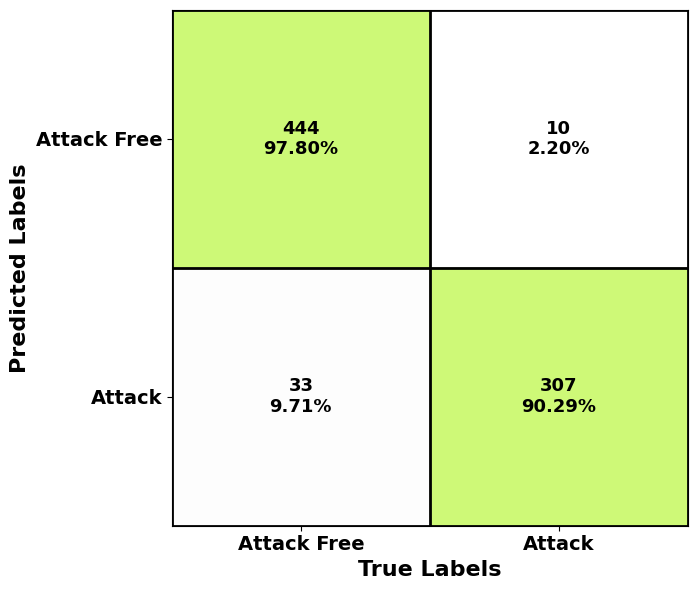

In [10]:
DATA_DIR = "Split_data/Test/Gen/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.54it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.06it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9763, 0.9941)


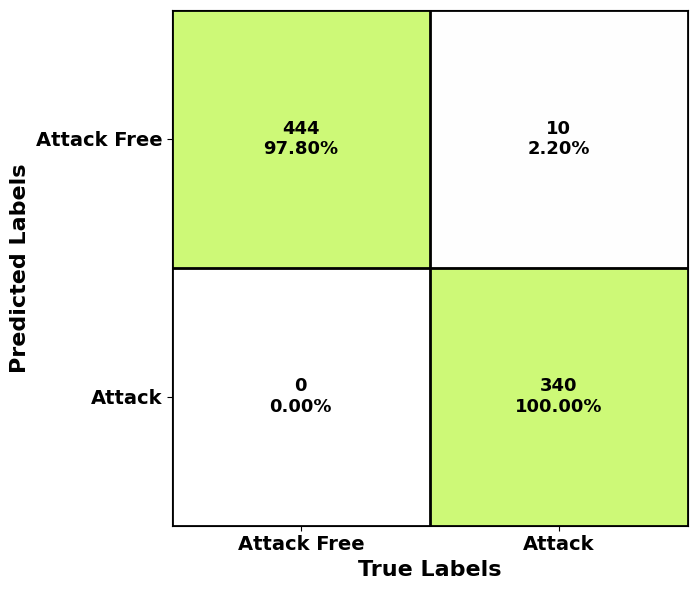

In [11]:
DATA_DIR = "Split_data/Test/Gen/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:01<00:01,  1.65s/it]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:02<00:00,  1.13s/it]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.04it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


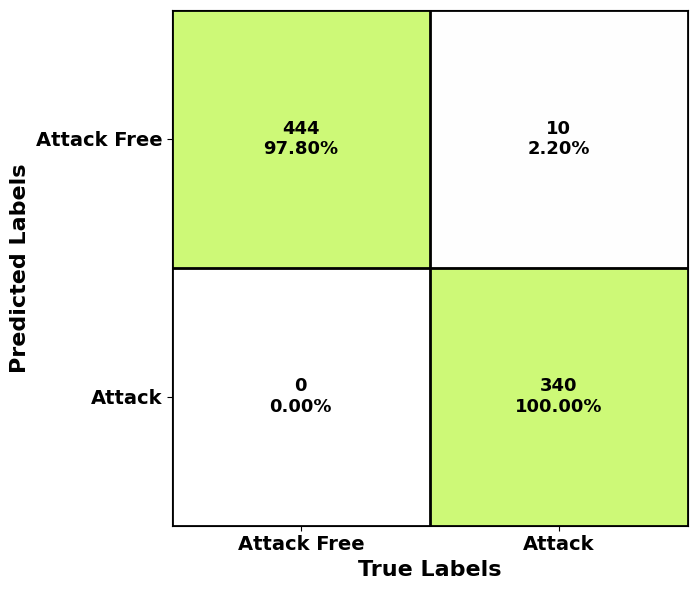

In [12]:
DATA_DIR = "Split_data/Test/Gen/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.18it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9763, 0.9941)


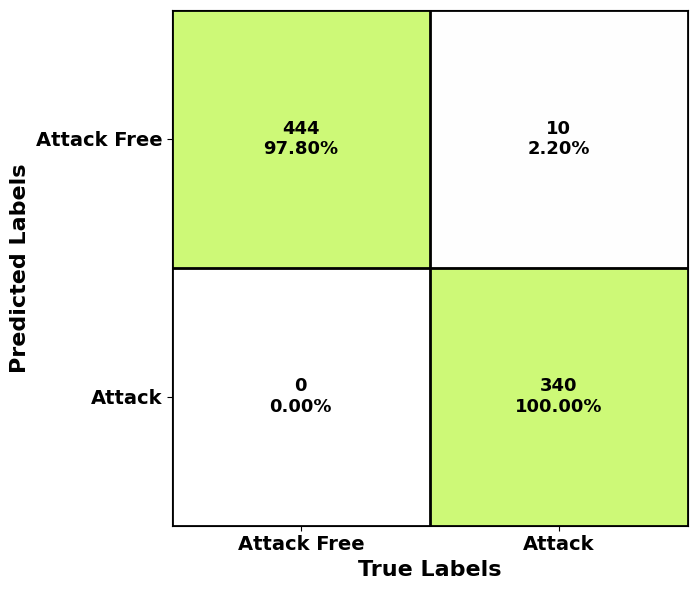

In [13]:
DATA_DIR = "Split_data/Test/Gen/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.67it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.65it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


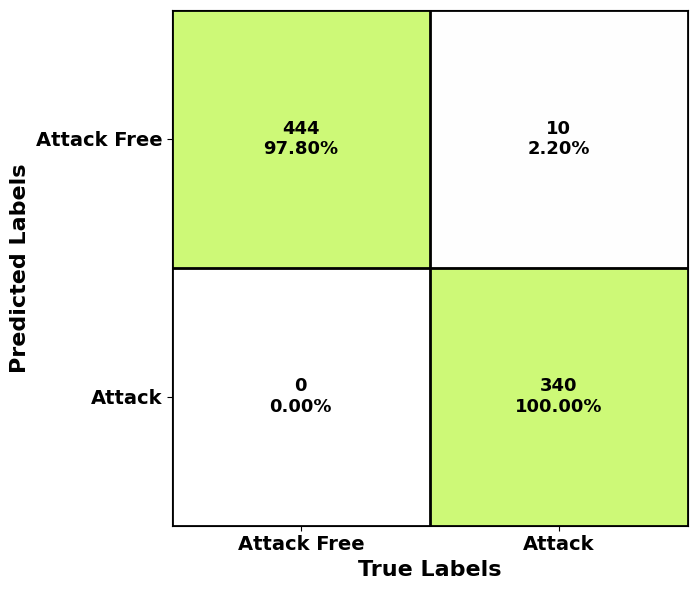

In [14]:
DATA_DIR = "Split_data/Test/Gen/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.61it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.64it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.12it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9761  (95% CI: 0.9629, 0.9846)
Precision: 0.9707  (95% CI: 0.9469, 0.9840)
Recall   : 0.9735  (95% CI: 0.9505, 0.9860)
F1-score : 0.9721  (95% CI: 0.9583, 0.9841)


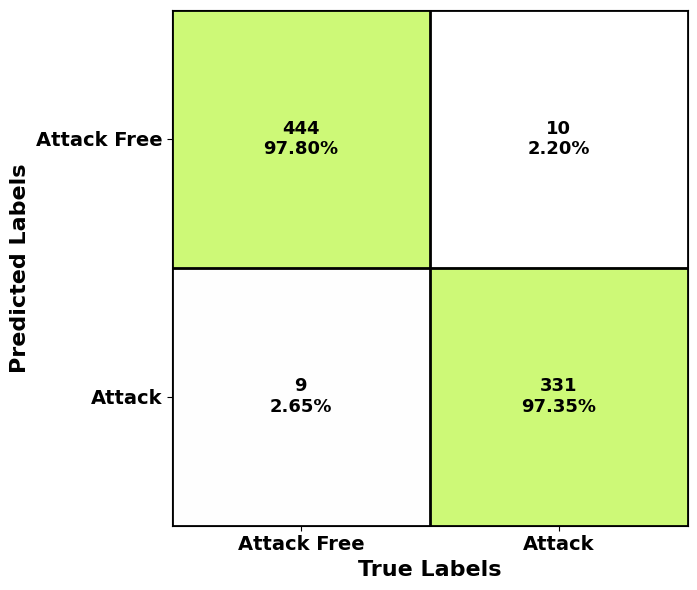

In [17]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.36it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.49it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.10it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


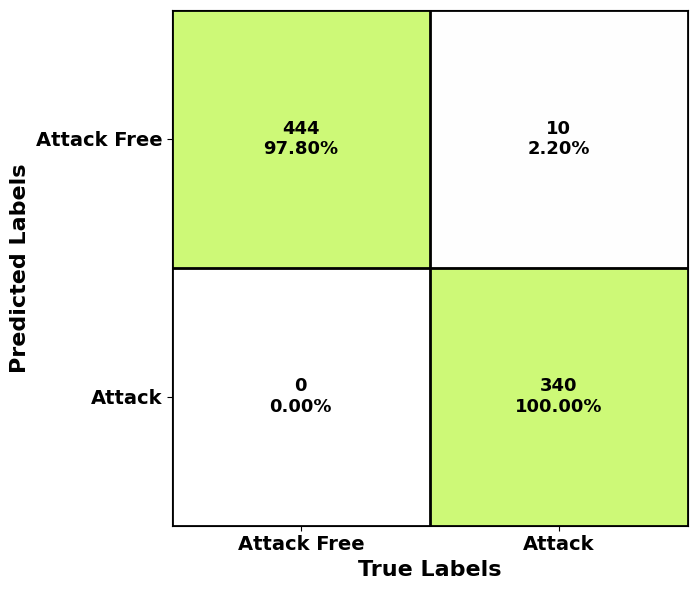

In [18]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.06it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.27it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.04it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


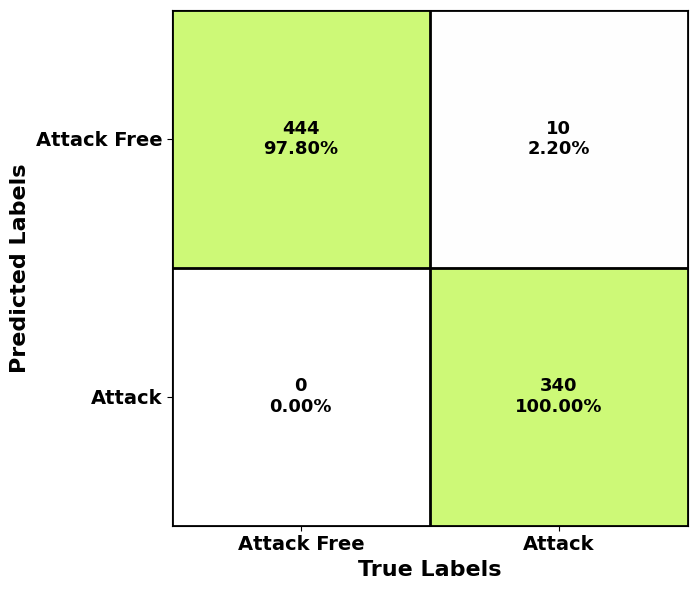

In [19]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:01<00:01,  1.01s/it]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.22it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


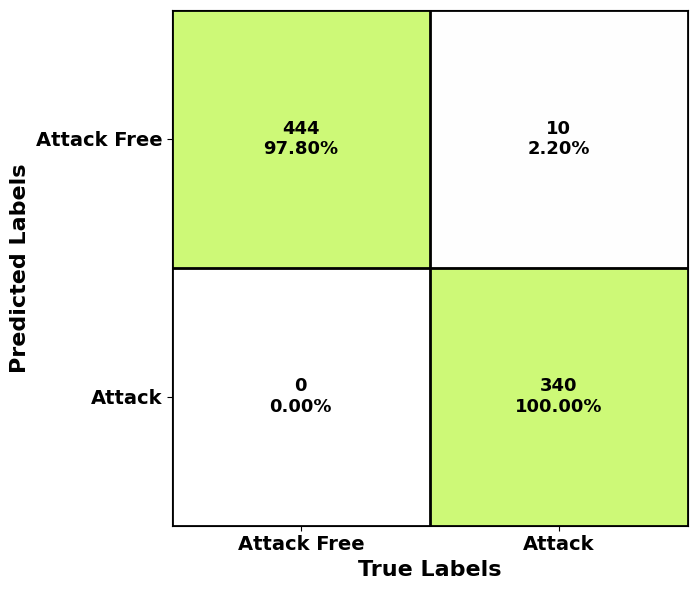

In [20]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.40it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.50it/s]


Total validation samples: 795


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.01it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9932)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9755, 0.9942)


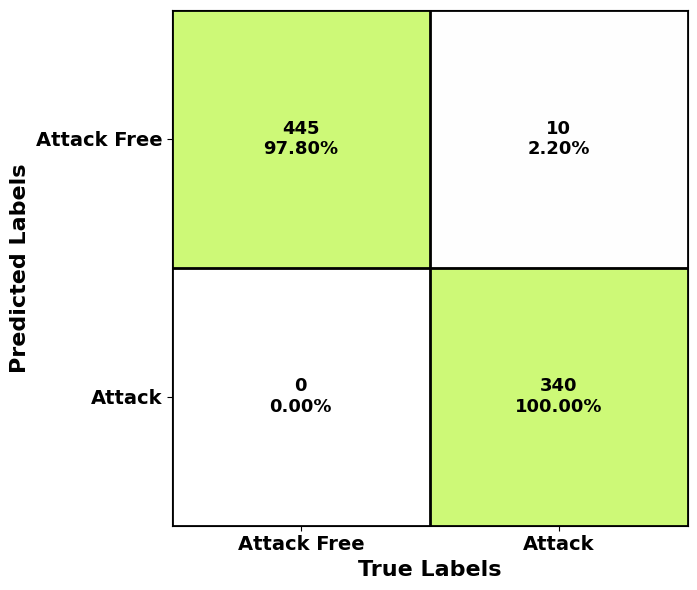

In [21]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.74it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.94it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9763, 0.9941)


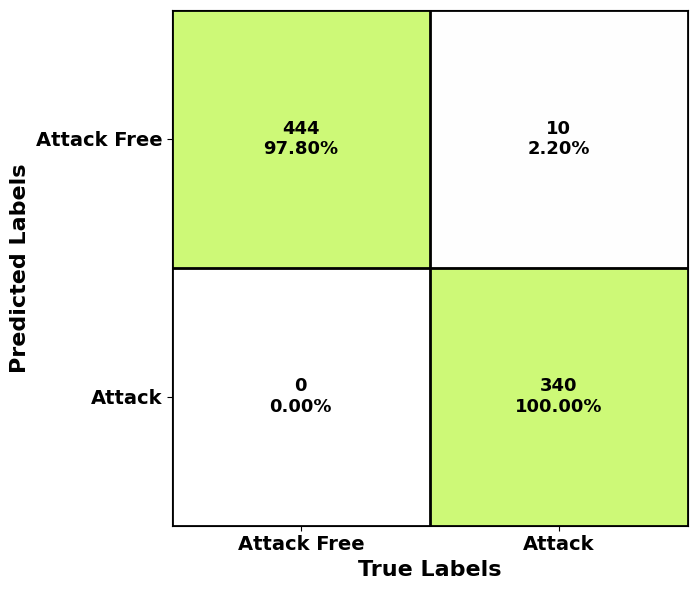

In [22]:
DATA_DIR = "Split_data/Test/Gen/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.64it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.12it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


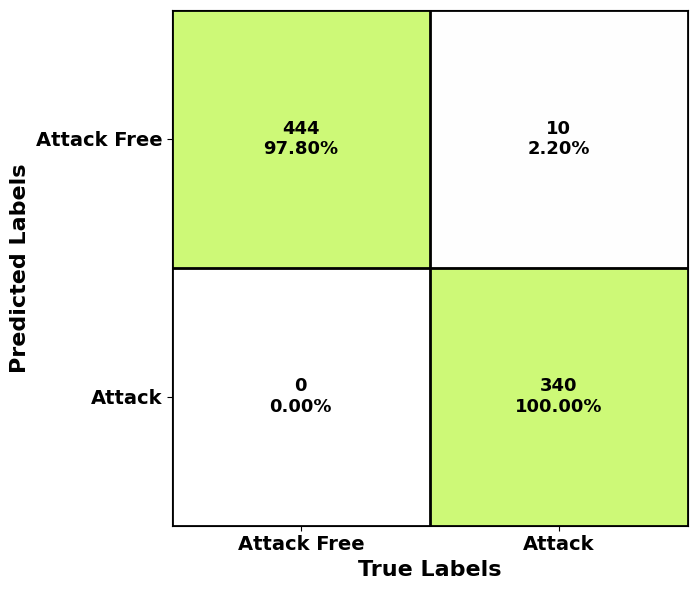

In [23]:
DATA_DIR = "Split_data/Test/Gen/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.60it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.02it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


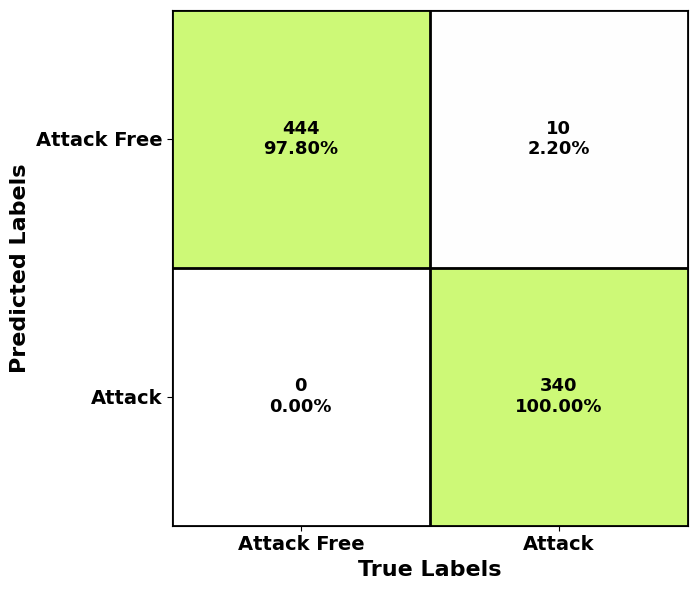

In [24]:
DATA_DIR = "Split_data/Test/Gen/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.49it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.56it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.99it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


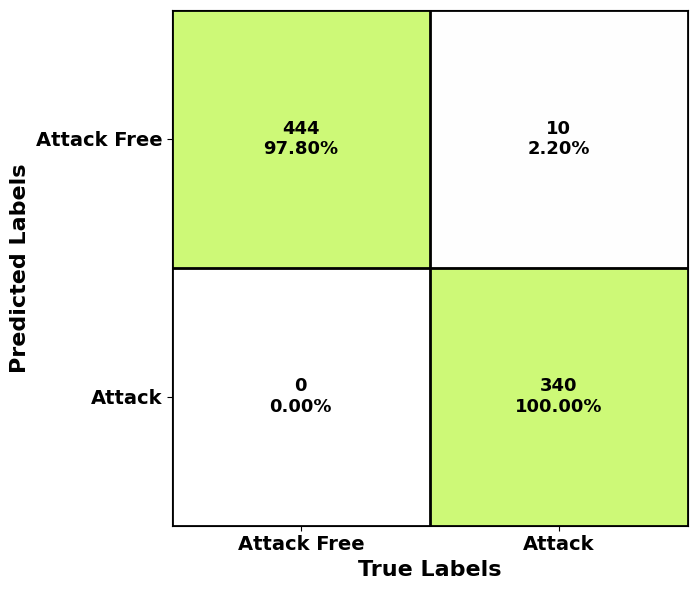

In [25]:
DATA_DIR = "Split_data/Test/Gen/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.81it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.03it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9763, 0.9941)


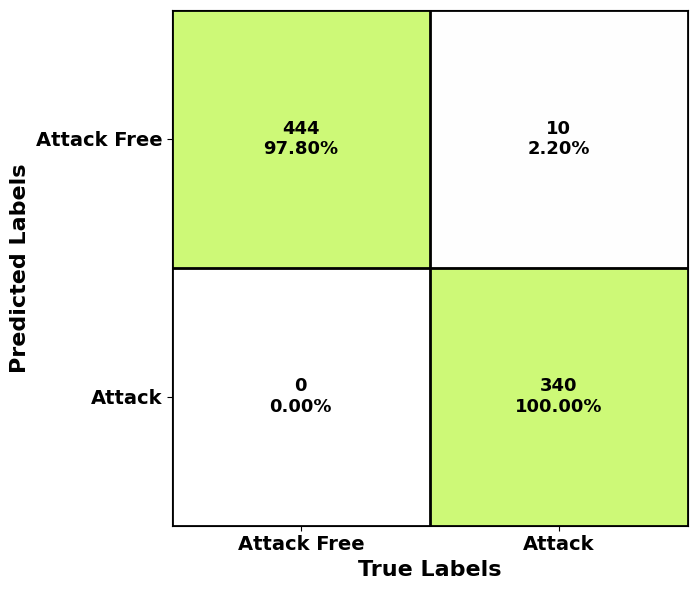

In [26]:
DATA_DIR = "Split_data/Test/Gen/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

In [66]:
import pandas as pd

Tesla_DoS_LL = pd.read_csv("Split_data/Test/Gen/DoS/Random/Gen_AF.csv")

/tmp/ipykernel_7694/2489343675.py:3: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  Tesla_DoS_LL = pd.read_csv("Split_data/Test/Gen/DoS/Random/Gen_AF.csv")


In [68]:
Tes = Tesla_DoS_LL[:120000]

In [69]:
Tes

,Time_Offset,CAN_ID,Data_Length,Data1,Data2,Data3,Data4,Data5,Data6,Data7,...,Data24,Data25,Data26,Data27,Data28,Data29,Data30,Data31,Data32,Label
0,0.262,041A,8,1B,00,52,00,00,00,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
1,0.586,00B5,13,81,D3,1D,92,00,7F,22,...,13,00,7A,00,9F,52,0,00,0,Normal
2,0.810,0100,13,79,EC,1D,00,14,CF,7E,...,00,FE,AF,2F,C2,6E,0,00,0,Normal
3,0.919,0422,8,53,30,11,00,11,15,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
4,1.446,0065,12,F0,73,0B,00,00,F4,FF,...,00,-1,-1,-1,-1,-1,-1,-1,-1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119995,47654.174,0155,10,39,17,A8,13,00,00,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
119996,47654.396,004A,13,9A,14,A8,00,00,00,02,...,00,00,00,00,00,00,0,00,0,Normal
119997,47656.268,0140,8,A8,9B,4E,41,80,00,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
119998,47656.473,0160,10,D4,F1,A7,03,00,00,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal


In [70]:
Tes.to_csv("Gen_AF.csv", index=False)

In [67]:
Tesla_DoS_LL

,Time_Offset,CAN_ID,Data_Length,Data1,Data2,Data3,Data4,Data5,Data6,Data7,...,Data24,Data25,Data26,Data27,Data28,Data29,Data30,Data31,Data32,Label
0,0.262,041A,8,1B,00,52,00,00,00,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
1,0.586,00B5,13,81,D3,1D,92,00,7F,22,...,13,00,7A,00,9F,52,0,00,0,Normal
2,0.810,0100,13,79,EC,1D,00,14,CF,7E,...,00,FE,AF,2F,C2,6E,0,00,0,Normal
3,0.919,0422,8,53,30,11,00,11,15,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
4,1.446,0065,12,F0,73,0B,00,00,F4,FF,...,00,-1,-1,-1,-1,-1,-1,-1,-1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,238019.939,012A,10,1C,2C,CB,1A,80,8E,17,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
599996,238020.463,041C,8,C8,70,20,17,01,00,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
599997,238021.136,01E5,10,B1,C2,2D,02,00,00,00,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,Normal
599998,238021.388,01BA,12,46,C1,2D,03,00,00,00,...,00,-1,-1,-1,-1,-1,-1,-1,-1,Normal
